<a href="https://colab.research.google.com/github/Shokoul/ECE662-Project1/blob/main/ECE662Proj1Task1_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1- Install and Import:**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models

**2- Prepare MNIST:**

In [ ]:
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

**3- Load AlexNet:**

In [ ]:
model = models.alexnet(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
model.classifier[6] = nn.Linear(4096,10)

**4- Define Loss and Optimizer:**

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

**5- Training Loop**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [ ]:
num_epochs = 10
for epoch in range(num_epochs):
  running_loss = 0.0

  for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    running_loss += loss.item()
  print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4}")

Epoch [1/10], Loss: 0.3487
Epoch [2/10], Loss: 0.1187
Epoch [3/10], Loss: 0.1021
Epoch [4/10], Loss: 0.08474
Epoch [5/10], Loss: 0.09584
Epoch [6/10], Loss: 0.07943
Epoch [7/10], Loss: 0.06716
Epoch [8/10], Loss: 0.08162
Epoch [9/10], Loss: 0.0827
Epoch [10/10], Loss: 0.06324


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**6- Saved Trained Weights**

Save only weights

In [ ]:
torch.save(model.state_dict(), "alexnet_mnist_weights.pth")

Save full model

In [ ]:
torch.save(model,"alexnet_mnist_full_model.pth")

**Load Model Later**

In [ ]:
model = models.alexnet()
model.classifier[6] = nn.Linear(4096, 10)
model.load_state_dict(torch.load("alexnet_mnist_weights.pth"))
model.eval()

**Task 1/Part2: PCA**

A DCF convolution layer (reconstruct W then doing conv2d)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.alexnet(weights=None)
model.classifier[6] = nn.Linear(4096, 10)   # MNIST has 10 classes
model.load_state_dict(torch.load("alexnet_mnist_weights.pth", map_location=device))
model = model.to(device)
model.eval()

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

Using device: cuda
Baseline accuracy: 98.45%
Baseline parameter count: 57044810
K= 1 | Test Accuracy=11.35% | DCF Params=54826660
K= 2 | Test Accuracy=11.35% | DCF Params=55076881
K= 4 | Test Accuracy=93.44% | DCF Params=55577323
K= 8 | Test Accuracy=97.91% | DCF Params=56578207
K=12 | Test Accuracy=97.93% | DCF Params=57579091
K=16 | Test Accuracy=98.25% | DCF Params=58579975
K=24 | Test Accuracy=98.49% | DCF Params=60581743
K=32 | Test Accuracy=98.51% | DCF Params=62583511
K=48 | Test Accuracy=98.48% | DCF Params=66587047
K=64 | Test Accuracy=98.45% | DCF Params=70590583


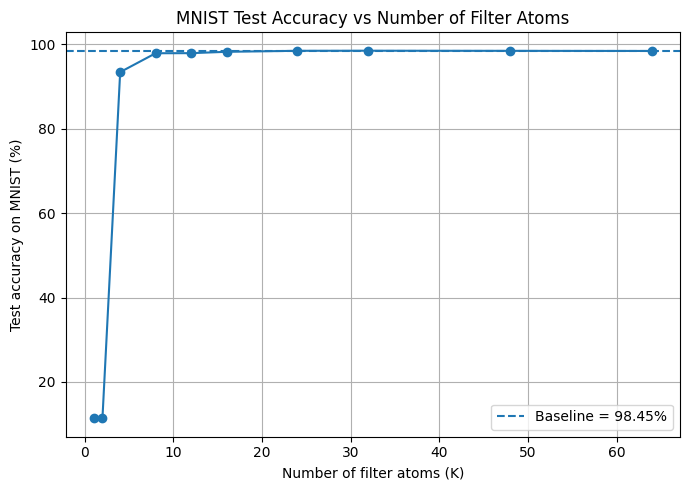

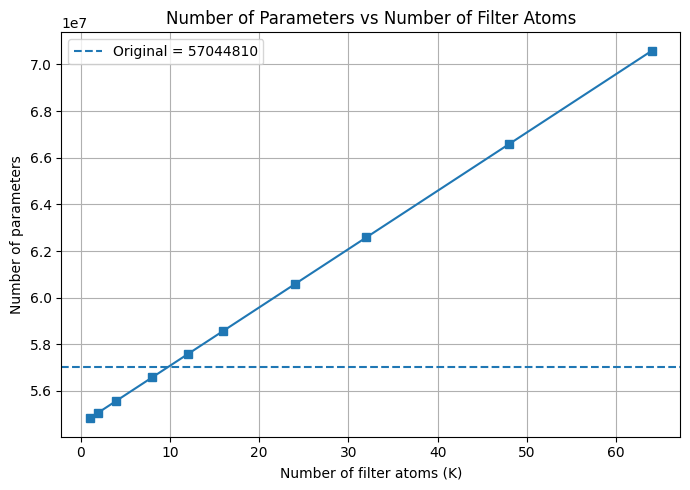

In [ ]:
import copy
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torchvision import models
import matplotlib.pyplot as plt

# ============================================================
# 1. Device
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ============================================================
# 2. MNIST test loader
# ============================================================
transform = transforms.Compose([
    transforms.Resize(224),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

# ============================================================
# 3. Load trained AlexNet
# ============================================================
model = models.alexnet(weights=None)
model.classifier[6] = nn.Linear(4096, 10)
model.load_state_dict(torch.load("alexnet_mnist_weights.pth", map_location=device))
model = model.to(device)
model.eval()

# ============================================================
# 4. Evaluation function
# ============================================================
def evaluate_accuracy(net, loader, device):
    net.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = net(images)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return 100.0 * correct / total

# ============================================================
# 5. PCA decomposition / reconstruction for conv weights
# ============================================================
def pca_decompose_conv_weight(conv_weight, K, include_mean=True):
    """
    conv_weight shape: [out_c, in_c_per_group, kH, kW]
    returns:
        atoms: [K, kH, kW]
        coeffs: [out_c, in_c_per_group, K]
        mean_filter: [kH, kW] or None
        recon_weight: [out_c, in_c_per_group, kH, kW]
    """
    out_c, in_c, kH, kW = conv_weight.shape
    assert kH == kW, "Only square kernels assumed here."

    W_mat = conv_weight.reshape(out_c * in_c, kH * kW)

    if include_mean:
        mean_vec = W_mat.mean(dim=0, keepdim=True)
        W_centered = W_mat - mean_vec
    else:
        mean_vec = torch.zeros(1, kH * kW, device=W_mat.device, dtype=W_mat.dtype)
        W_centered = W_mat

    U, S, Vh = torch.linalg.svd(W_centered, full_matrices=False)

    max_rank = Vh.shape[0]
    K_eff = min(K, max_rank)

    Vk = Vh[:K_eff]                              # [K_eff, kH*kW]
    atoms = Vk.reshape(K_eff, kH, kW)
    coeffs_mat = W_centered @ Vk.T              # [(out_c*in_c), K_eff]
    coeffs = coeffs_mat.reshape(out_c, in_c, K_eff)

    W_recon_mat = coeffs_mat @ Vk + mean_vec
    recon_weight = W_recon_mat.reshape(out_c, in_c, kH, kW)

    mean_filter = mean_vec.reshape(kH, kW) if include_mean else None
    return atoms, coeffs, mean_filter, recon_weight

# ============================================================
# 6. Replace AlexNet conv weights with PCA-reconstructed weights
# ============================================================
def build_pca_reconstructed_model(base_model, K, include_mean=True):
    """
    Returns a copy of base_model where each conv layer in AlexNet
    is replaced by its PCA-reconstructed weights using top-K atoms.
    """
    new_model = copy.deepcopy(base_model)

    conv_indices = [0, 3, 6, 8, 10]

    for idx in conv_indices:
        conv = new_model.features[idx]
        W = conv.weight.data.clone()

        atoms, coeffs, mean_filter, W_recon = pca_decompose_conv_weight(
            W, K=K, include_mean=include_mean
        )

        conv.weight.data.copy_(W_recon)

    return new_model

# ============================================================
# 7. Count parameters in DCF representation
# ============================================================
def count_dcf_conv_params(conv_layer, K, include_mean=True):
    """
    For a conv weight W in R^{c' x c x l x l} (here c means in_channels_per_group),
    DCF parameters are:
      - atoms: K * l * l
      - coefficients: c' * c * K
      - optional mean: l * l
      - bias: out_channels (if bias exists)
    """
    out_c, in_c, kH, kW = conv_layer.weight.shape
    params = K * kH * kW + out_c * in_c * K

    if include_mean:
        params += kH * kW

    if conv_layer.bias is not None:
        params += conv_layer.bias.numel()

    return params

def count_total_dcf_model_params(base_model, K, include_mean=True):
    """
    Count total parameters assuming:
    - conv layers are stored in DCF form
    - all non-conv layers remain unchanged
    """
    conv_indices = [0, 3, 6, 8, 10]
    total = 0

    for idx, layer in enumerate(base_model.features):
        if isinstance(layer, nn.Conv2d):
            if idx in conv_indices:
                total += count_dcf_conv_params(layer, K, include_mean=include_mean)
            else:
                total += sum(p.numel() for p in layer.parameters())

    # classifier + any remaining params
    total += sum(p.numel() for p in base_model.classifier.parameters())

    return total

def count_original_model_params(net):
    return sum(p.numel() for p in net.parameters())

# ============================================================
# 8. Sweep over K values
# ============================================================
K_values = [1, 2, 4, 8, 12, 16, 24, 32, 48, 64]

accuracies = []
param_counts = []

baseline_acc = evaluate_accuracy(model, test_loader, device)
baseline_params = count_original_model_params(model)

print(f"Baseline accuracy: {baseline_acc:.2f}%")
print(f"Baseline parameter count: {baseline_params}")

for K in K_values:
    pca_model = build_pca_reconstructed_model(model, K=K, include_mean=True)
    pca_model = pca_model.to(device)

    acc = evaluate_accuracy(pca_model, test_loader, device)
    params = count_total_dcf_model_params(model, K=K, include_mean=True)

    accuracies.append(acc)
    param_counts.append(params)

    print(f"K={K:2d} | Test Accuracy={acc:.2f}% | DCF Params={params}")

# ============================================================
# 9. Plot 1: Test accuracy vs number of filter atoms
# ============================================================
plt.figure(figsize=(7, 5))
plt.plot(K_values, accuracies, marker='o')
plt.axhline(y=baseline_acc, linestyle='--', label=f'Baseline = {baseline_acc:.2f}%')
plt.xlabel("Number of filter atoms (K)")
plt.ylabel("Test accuracy on MNIST (%)")
plt.title("MNIST Test Accuracy vs Number of Filter Atoms")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================================
# 10. Plot 2: Number of parameters vs number of filter atoms
# ============================================================
plt.figure(figsize=(7, 5))
plt.plot(K_values, param_counts, marker='s')
plt.axhline(y=baseline_params, linestyle='--', label=f'Original = {baseline_params}')
plt.xlabel("Number of filter atoms (K)")
plt.ylabel("Number of parameters")
plt.title("Number of Parameters vs Number of Filter Atoms")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
K_per_layer = {0: 8, 3: 16, 6: 24, 8: 24, 10: 16}

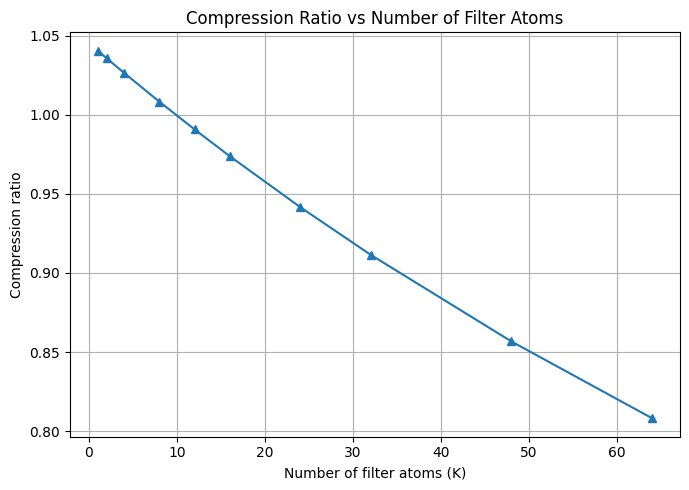

In [ ]:
compression_ratio = [baseline_params / p for p in param_counts]

plt.figure(figsize=(7, 5))
plt.plot(K_values, compression_ratio, marker='^')
plt.xlabel("Number of filter atoms (K)")
plt.ylabel("Compression ratio")
plt.title("Compression Ratio vs Number of Filter Atoms")
plt.grid(True)
plt.tight_layout()
plt.show()

Task 2: Compare Filter Atoms with Fourier-Bassel Bases

In [ ]:
pip install torch torchvision matplotlib scipy

In [ ]:
import os
import math
import copy
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv, jn_zeros

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models


# ============================================================
# Configuration
# ============================================================
ALEXNET_WEIGHTS_PATH = "alexnet_mnist_weights.pth"
SAVE_FB_MODEL_PATH = "alexnet_mnist_fourier_bessel.pth"
SAVE_CHECKPOINT_PATH = "alexnet_mnist_fourier_bessel_checkpoint.pth"
SAVE_FIG_PATH = "fb_vs_pca_conv1.png"

BATCH_SIZE_TRAIN = 64
BATCH_SIZE_TEST = 128
NUM_EPOCHS = 5
LEARNING_RATE = 1e-3

# Fourier-Bessel basis configuration by kernel size
FB_CONFIG = {
    11: {"max_angular": 3, "max_radial": 3},
    5:  {"max_angular": 2, "max_radial": 2},
    3:  {"max_angular": 1, "max_radial": 2},
}

# Number of PCA atoms to visualize for conv1
NUM_VIS_ATOMS = 8

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ============================================================
# Utilities
# ============================================================
def evaluate_accuracy(model, loader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return 100.0 * correct / total


def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# ============================================================
# MNIST data
# ============================================================
def get_mnist_loaders():
    transform = transforms.Compose([
        transforms.Resize(224),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    train_dataset = torchvision.datasets.MNIST(
        root="./data",
        train=True,
        download=True,
        transform=transform
    )

    test_dataset = torchvision.datasets.MNIST(
        root="./data",
        train=False,
        download=True,
        transform=transform
    )

    train_loader = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE_TRAIN,
        shuffle=True,
        num_workers=2,
        pin_memory=torch.cuda.is_available()
    )

    test_loader = torch.utils.data.DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE_TEST,
        shuffle=False,
        num_workers=2,
        pin_memory=torch.cuda.is_available()
    )

    return train_loader, test_loader


# ============================================================
# PCA for conv filters
# ============================================================
def pca_decompose_conv_weight(conv_weight, K, include_mean=True):
    """
    conv_weight: [out_c, in_c_per_group, kH, kW]

    Returns:
        atoms: [K_eff, kH, kW]
        coeffs: [out_c, in_c_per_group, K_eff]
        mean_filter: [kH, kW] or None
    """
    out_c, in_c, kH, kW = conv_weight.shape
    assert kH == kW, "Square kernels are assumed."

    W_mat = conv_weight.reshape(out_c * in_c, kH * kW)

    if include_mean:
        mean_vec = W_mat.mean(dim=0, keepdim=True)
        W_centered = W_mat - mean_vec
    else:
        mean_vec = torch.zeros(1, kH * kW, device=W_mat.device, dtype=W_mat.dtype)
        W_centered = W_mat

    U, S, Vh = torch.linalg.svd(W_centered, full_matrices=False)
    K_eff = min(K, Vh.shape[0])

    Vk = Vh[:K_eff]  # [K_eff, kH*kW]
    atoms = Vk.reshape(K_eff, kH, kW)
    coeffs = (W_centered @ Vk.T).reshape(out_c, in_c, K_eff)

    mean_filter = mean_vec.reshape(kH, kW) if include_mean else None
    return atoms, coeffs, mean_filter


# ============================================================
# Fourier-Bessel basis generation
# ============================================================
def make_polar_grid(kernel_size):
    coords = np.linspace(-(kernel_size - 1) / 2, (kernel_size - 1) / 2, kernel_size)
    yy, xx = np.meshgrid(coords, coords, indexing='ij')
    radius = (kernel_size - 1) / 2

    r = np.sqrt(xx**2 + yy**2) / radius
    theta = np.arctan2(yy, xx)
    mask = (r <= 1.0).astype(np.float32)

    return r, theta, mask


def generate_fourier_bessel_bases(kernel_size, max_angular=3, max_radial=3):
    """
    Generates real-valued Fourier-Bessel bases on a discrete l x l grid.

    Returns:
        bases_ortho: torch.FloatTensor [Q, l, l]
        labels: list[str]
    """
    r, theta, mask = make_polar_grid(kernel_size)

    basis_list = []
    labels = []

    for m in range(max_angular + 1):
        zeros = jn_zeros(m, max_radial)

        for n_idx, alpha_mn in enumerate(zeros, start=1):
            radial = jv(m, alpha_mn * r) * mask

            if m == 0:
                basis = radial
                basis_list.append(basis)
                labels.append(f"m=0,n={n_idx}")
            else:
                basis_cos = radial * np.cos(m * theta) * mask
                basis_sin = radial * np.sin(m * theta) * mask

                basis_list.append(basis_cos)
                labels.append(f"m={m},n={n_idx},cos")

                basis_list.append(basis_sin)
                labels.append(f"m={m},n={n_idx},sin")

    bases = np.stack(basis_list, axis=0)  # [Q, l, l]

    # Orthonormalize numerically on discrete grid using QR
    Qb, l, _ = bases.shape
    B = bases.reshape(Qb, -1).T  # [l*l, Qb]
    Qmat, _ = np.linalg.qr(B)    # [l*l, rank]

    bases_ortho = Qmat.T.reshape(-1, l, l)
    labels = labels[:bases_ortho.shape[0]]

    return torch.tensor(bases_ortho, dtype=torch.float32), labels


# ============================================================
# Fourier-Bessel Conv2d
# ============================================================
class FBConv2d(nn.Module):
    def __init__(self, conv_layer, basis_bank):
        """
        conv_layer: nn.Conv2d
        basis_bank: [Q, kH, kW], fixed
        """
        super().__init__()
        assert isinstance(conv_layer, nn.Conv2d)

        out_c = conv_layer.out_channels
        in_c_per_group = conv_layer.in_channels // conv_layer.groups
        kH, kW = conv_layer.kernel_size
        Q = basis_bank.shape[0]

        self.out_channels = out_c
        self.in_channels = conv_layer.in_channels
        self.in_c_per_group = in_c_per_group
        self.kernel_size = conv_layer.kernel_size
        self.stride = conv_layer.stride
        self.padding = conv_layer.padding
        self.dilation = conv_layer.dilation
        self.groups = conv_layer.groups

        self.register_buffer("basis_bank", basis_bank.clone())  # [Q, kH, kW]

        # Learnable coefficients: [out_c, in_c_per_group, Q]
        self.coeffs = nn.Parameter(torch.zeros(out_c, in_c_per_group, Q))

        if conv_layer.bias is not None:
            self.bias = nn.Parameter(conv_layer.bias.detach().clone())
        else:
            self.bias = None

        # Initialize coeffs from original weights by projection
        with torch.no_grad():
            W = conv_layer.weight.data.clone()                           # [out_c, in_c_per_group, kH, kW]
            W_flat = W.reshape(out_c * in_c_per_group, -1)              # [out_c*in_c_per_group, kH*kW]
            B_flat = self.basis_bank.reshape(Q, -1)                     # [Q, kH*kW]

            # Approximate orthonormal basis => projection by inner product
            C = W_flat @ B_flat.T                                       # [out_c*in_c_per_group, Q]
            self.coeffs.copy_(C.reshape(out_c, in_c_per_group, Q))

    def reconstruct_weight(self):
        Q, kH, kW = self.basis_bank.shape
        B_flat = self.basis_bank.reshape(Q, -1)                         # [Q, kH*kW]
        C_flat = self.coeffs.reshape(-1, Q)                             # [out_c*in_c_per_group, Q]
        W_flat = C_flat @ B_flat                                        # [out_c*in_c_per_group, kH*kW]
        W = W_flat.reshape(self.out_channels, self.in_c_per_group, kH, kW)
        return W

    def forward(self, x):
        W = self.reconstruct_weight()
        return F.conv2d(
            x,
            W,
            self.bias,
            stride=self.stride,
            padding=self.padding,
            dilation=self.dilation,
            groups=self.groups
        )


# ============================================================
# Build Fourier-Bessel AlexNet
# ============================================================
def replace_alexnet_convs_with_fb(model, fb_config):
    """
    Replaces AlexNet conv layers with FBConv2d layers.
    Returns:
        new_model
        basis_cache: dict[kernel_size] = (basis_bank, labels)
    """
    new_model = copy.deepcopy(model)
    conv_indices = [0, 3, 6, 8, 10]
    basis_cache = {}

    for idx in conv_indices:
        conv = new_model.features[idx]
        k = conv.kernel_size[0]

        if k not in basis_cache:
            config = fb_config[k]
            basis_bank, labels = generate_fourier_bessel_bases(
                kernel_size=k,
                max_angular=config["max_angular"],
                max_radial=config["max_radial"]
            )
            basis_cache[k] = (basis_bank.to(DEVICE), labels)

        basis_bank, _ = basis_cache[k]
        new_model.features[idx] = FBConv2d(conv, basis_bank)

    return new_model, basis_cache


# ============================================================
# Visualization
# ============================================================
def save_fb_vs_pca_figure(fb_bases, fb_labels, pca_atoms, save_path, n_show=8):
    n = min(n_show, fb_bases.shape[0], pca_atoms.shape[0])

    fig, axes = plt.subplots(2, n, figsize=(3 * n, 6))

    for i in range(n):
        ax1 = axes[0, i]
        im1 = ax1.imshow(fb_bases[i].cpu().numpy(), cmap="seismic")
        ax1.set_title(f"FB #{i+1}\n{fb_labels[i] if i < len(fb_labels) else ''}", fontsize=9)
        ax1.axis("off")

        ax2 = axes[1, i]
        im2 = ax2.imshow(pca_atoms[i].cpu().numpy(), cmap="seismic")
        ax2.set_title(f"PCA Atom #{i+1}", fontsize=9)
        ax2.axis("off")

    fig.suptitle("Fourier–Bessel Bases vs PCA Filter Atoms (AlexNet conv1)", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close(fig)


# ============================================================
# Main
# ============================================================
def main():
    print("Using device:", DEVICE)

    # --------------------------------------------------------
    # Data
    # --------------------------------------------------------
    train_loader, test_loader = get_mnist_loaders()

    # --------------------------------------------------------
    # Load trained AlexNet
    # --------------------------------------------------------
    if not os.path.exists(ALEXNET_WEIGHTS_PATH):
        raise FileNotFoundError(f"Could not find '{ALEXNET_WEIGHTS_PATH}'")

    alexnet = models.alexnet(weights=None)
    alexnet.classifier[6] = nn.Linear(4096, 10)
    alexnet.load_state_dict(torch.load(ALEXNET_WEIGHTS_PATH, map_location=DEVICE))
    alexnet = alexnet.to(DEVICE)

    baseline_acc = evaluate_accuracy(alexnet, test_loader, DEVICE)
    print(f"Loaded AlexNet baseline test accuracy: {baseline_acc:.2f}%")

    # --------------------------------------------------------
    # Build Fourier-Bessel AlexNet
    # --------------------------------------------------------
    fb_model, basis_cache = replace_alexnet_convs_with_fb(alexnet, FB_CONFIG)
    fb_model = fb_model.to(DEVICE)

    # Freeze everything first
    for param in fb_model.parameters():
        param.requires_grad = False

    # Train Fourier-Bessel coefficients and conv biases
    for module in fb_model.modules():
        if isinstance(module, FBConv2d):
            module.coeffs.requires_grad = True
            if module.bias is not None:
                module.bias.requires_grad = True

    # Also fine-tune classifier
    for param in fb_model.classifier.parameters():
        param.requires_grad = True

    print(f"Trainable parameters in FB model: {count_trainable_params(fb_model)}")

    # --------------------------------------------------------
    # Save comparison figure: Fourier-Bessel bases vs PCA atoms
    # Use conv1 (11x11)
    # --------------------------------------------------------
    conv1_weight = alexnet.features[0].weight.data.clone()
    pca_atoms, _, _ = pca_decompose_conv_weight(conv1_weight, K=NUM_VIS_ATOMS, include_mean=True)

    fb_bases_11, fb_labels_11 = basis_cache[11]
    save_fb_vs_pca_figure(
        fb_bases=fb_bases_11.cpu(),
        fb_labels=fb_labels_11,
        pca_atoms=pca_atoms.cpu(),
        save_path=SAVE_FIG_PATH,
        n_show=NUM_VIS_ATOMS
    )
    print(f"Saved comparison figure to: {SAVE_FIG_PATH}")

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, fb_model.parameters()),
        lr=LEARNING_RATE
    )

    history = {
        "train_loss": [],
        "test_acc": []
    }

    for epoch in range(NUM_EPOCHS):
        fb_model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = fb_model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        test_acc = evaluate_accuracy(fb_model, test_loader, DEVICE)

        history["train_loss"].append(avg_loss)
        history["test_acc"].append(test_acc)

        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]  Loss: {avg_loss:.4f}  Test Acc: {test_acc:.2f}%")

    # --------------------------------------------------------
    # Save model
    # --------------------------------------------------------
    torch.save(fb_model.state_dict(), SAVE_FB_MODEL_PATH)
    print(f"Saved trained FB model state_dict to: {SAVE_FB_MODEL_PATH}")

    checkpoint = {
        "model_state_dict": fb_model.state_dict(),
        "history": history,
        "fb_config": FB_CONFIG,
        "baseline_acc": baseline_acc
    }
    torch.save(checkpoint, SAVE_CHECKPOINT_PATH)
    print(f"Saved checkpoint to: {SAVE_CHECKPOINT_PATH}")

    final_acc = evaluate_accuracy(fb_model, test_loader, DEVICE)
    print(f"Final Fourier-Bessel AlexNet test accuracy: {final_acc:.2f}%")


if __name__ == "__main__":
    main()

Using device: cuda
Loaded AlexNet baseline test accuracy: 98.45%
Trainable parameters in FB model: 56128586
Saved comparison figure to: fb_vs_pca_conv1.png
Epoch [1/5]  Loss: 0.0982  Test Acc: 99.21%
Epoch [2/5]  Loss: 0.0600  Test Acc: 98.58%
Epoch [3/5]  Loss: 0.0480  Test Acc: 99.23%
Epoch [4/5]  Loss: 0.0460  Test Acc: 99.21%
Epoch [5/5]  Loss: 0.0523  Test Acc: 99.12%
Saved trained FB model state_dict to: alexnet_mnist_fourier_bessel.pth
Saved checkpoint to: alexnet_mnist_fourier_bessel_checkpoint.pth
Final Fourier-Bessel AlexNet test accuracy: 99.12%


Task 3

Using device: cuda

=== Pretraining baseline denoising autoencoder ===
Epoch [1/5] loss=0.115567 test PSNR=9.7040 dB
Epoch [2/5] loss=0.112003 test PSNR=9.7040 dB
Epoch [3/5] loss=0.112006 test PSNR=9.7040 dB
Epoch [4/5] loss=0.112002 test PSNR=9.7040 dB
Epoch [5/5] loss=0.111999 test PSNR=9.7040 dB

Baseline PSNR: 9.7040 dB
Baseline parameter count: 46529

=== Running mode = fb ===

--- mode=fb, K=1 ---
Epoch [1/3] loss=0.088456 test PSNR=11.5556 dB
Epoch [2/3] loss=0.071557 test PSNR=11.5586 dB
Epoch [3/3] loss=0.071484 test PSNR=11.5699 dB
Final: mode=fb, K=1, PSNR=11.5808 dB, params=25793

--- mode=fb, K=2 ---
Epoch [1/3] loss=0.112010 test PSNR=9.7040 dB
Epoch [2/3] loss=0.112000 test PSNR=9.7040 dB
Epoch [3/3] loss=0.112001 test PSNR=9.7040 dB
Final: mode=fb, K=2, PSNR=9.7040 dB, params=28385

--- mode=fb, K=4 ---
Epoch [1/3] loss=0.112005 test PSNR=9.7040 dB
Epoch [2/3] loss=0.112003 test PSNR=9.7040 dB
Epoch [3/3] loss=0.112005 test PSNR=9.7040 dB
Final: mode=fb, K=4, PSNR=9.70

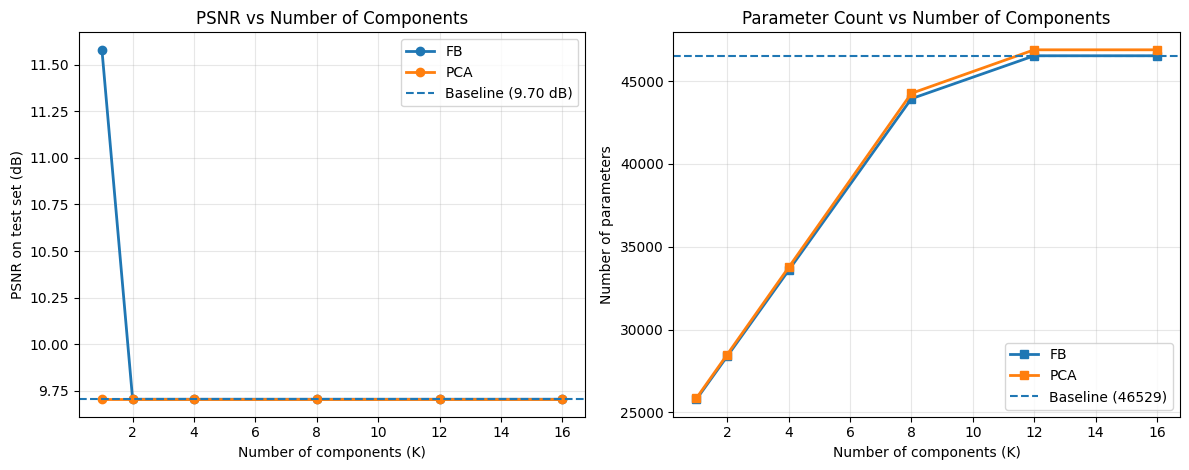

Saved main figure to: ./ae_dcf_results/psnr_and_params_vs_components.png


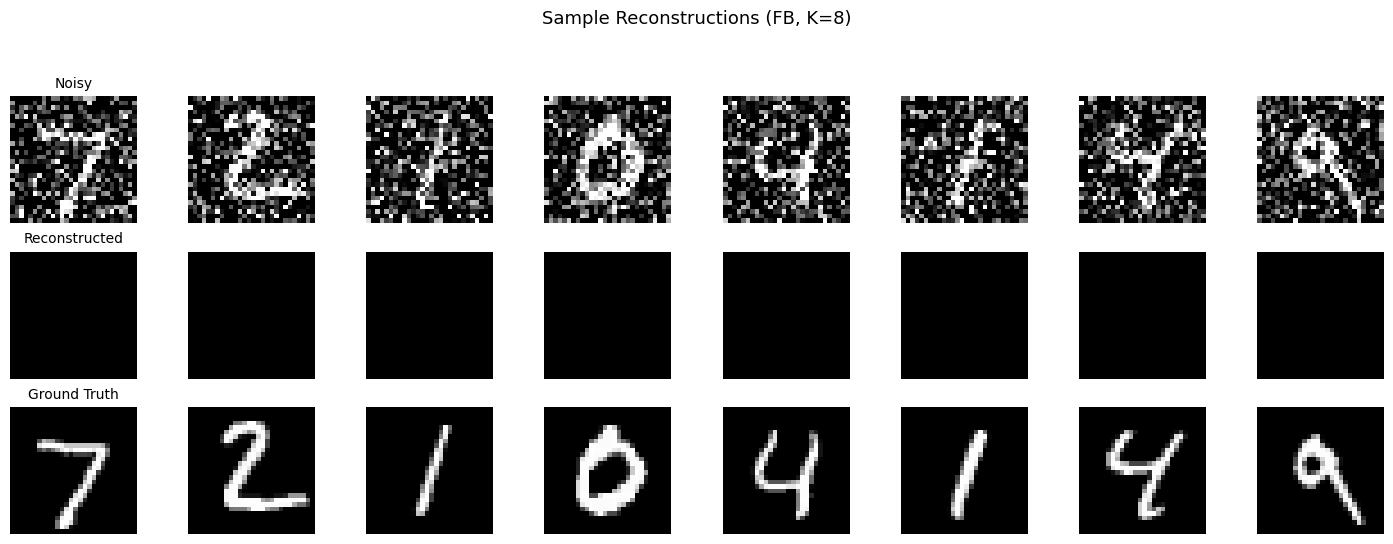

Saved reconstruction figure to: ./ae_dcf_results/sample_reconstructions.png

=== Summary ===
Baseline: PSNR=9.7040 dB, params=46529

Mode: fb
  K= 1  PSNR=11.5808 dB  params=25793
  K= 2  PSNR=9.7040 dB  params=28385
  K= 4  PSNR=9.7040 dB  params=33569
  K= 8  PSNR=9.7040 dB  params=43937
  K=12  PSNR=9.7040 dB  params=46529
  K=16  PSNR=9.7040 dB  params=46529

Mode: pca
  K= 1  PSNR=9.7040 dB  params=25865
  K= 2  PSNR=9.7040 dB  params=28493
  K= 4  PSNR=9.7040 dB  params=33749
  K= 8  PSNR=9.7040 dB  params=44261
  K=12  PSNR=9.7040 dB  params=46889
  K=16  PSNR=9.7040 dB  params=46889


In [ ]:
import os
import math
import copy
import random
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv, jn_zeros

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms


# ============================================================
# Configuration
# ============================================================
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_DIR = "./data"
OUT_DIR = "./ae_dcf_results"
os.makedirs(OUT_DIR, exist_ok=True)

PRETRAIN_MODEL_PATH = os.path.join(OUT_DIR, "dae_pretrained.pth")
RESULTS_NPZ = os.path.join(OUT_DIR, "psnr_results.npz")
MAIN_FIG_PATH = os.path.join(OUT_DIR, "psnr_and_params_vs_components.png")
RECON_FIG_PATH = os.path.join(OUT_DIR, "sample_reconstructions.png")

BATCH_SIZE_TRAIN = 128
BATCH_SIZE_TEST = 256
PRETRAIN_EPOCHS = 5
FINETUNE_EPOCHS = 3
LR_PRETRAIN = 1e-3
LR_FINETUNE = 1e-3

NOISE_STD = 0.5
K_VALUES = [1, 2, 4, 8, 12, 16]
MODES = ["fb", "pca"]   # use ["fb"] if you only want Fourier-Bessel

NUM_RECON_SAMPLES = 8
RECON_VIS_MODE = "fb"   # which mode to visualize for sample reconstructions
RECON_VIS_K = 8         # which K to visualize for sample reconstructions

FB_CONFIG = {
    3: {"max_angular": 1, "max_radial": 3},
}


# ============================================================
# Reproducibility
# ============================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)


# ============================================================
# Dataset
# ============================================================
class NoisyMNIST(torchvision.datasets.MNIST):
    def __init__(self, root, train=True, download=True, noise_std=0.5):
        transform = transforms.ToTensor()
        super().__init__(root=root, train=train, download=download, transform=transform)
        self.noise_std = noise_std

    def __getitem__(self, index):
        clean_img, _ = super().__getitem__(index)    # [1, 28, 28]
        noise = torch.randn_like(clean_img) * self.noise_std
        noisy_img = torch.clamp(clean_img + noise, 0.0, 1.0)
        return noisy_img, clean_img


def get_loaders(noise_std=0.5):
    train_ds = NoisyMNIST(DATA_DIR, train=True, download=True, noise_std=noise_std)
    test_ds = NoisyMNIST(DATA_DIR, train=False, download=True, noise_std=noise_std)

    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE_TRAIN,
        shuffle=True,
        num_workers=2,
        pin_memory=torch.cuda.is_available()
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=BATCH_SIZE_TEST,
        shuffle=False,
        num_workers=2,
        pin_memory=torch.cuda.is_available()
    )
    return train_loader, test_loader


# ============================================================
# PSNR
# ============================================================
def batch_psnr(pred, target, max_val=1.0):
    mse = F.mse_loss(pred, target, reduction="none")
    mse = mse.flatten(1).mean(dim=1)
    eps = 1e-10
    psnr = 10.0 * torch.log10((max_val ** 2) / (mse + eps))
    return psnr.mean().item()


def evaluate_psnr(model, loader, device):
    model.eval()
    psnr_vals = []

    with torch.no_grad():
        for noisy, clean in loader:
            noisy = noisy.to(device)
            clean = clean.to(device)
            recon = torch.clamp(model(noisy), 0.0, 1.0)
            psnr_vals.append(batch_psnr(recon, clean))

    return float(np.mean(psnr_vals))


# ============================================================
# Baseline Autoencoder
# ============================================================
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1)
        self.enc2 = nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1)
        self.enc3 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)

        self.dec1 = nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.dec2 = nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.dec3 = nn.Conv2d(16, 1, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        x = F.relu(self.enc1(x))
        x = F.relu(self.enc2(x))
        x = F.relu(self.enc3(x))
        x = F.relu(self.dec1(x))
        x = F.relu(self.dec2(x))
        x = torch.sigmoid(self.dec3(x))
        return x


# ============================================================
# PCA decomposition
# ============================================================
def decompose_conv_atoms_from_weight(weight, K):
    out_c, in_c, kH, kW = weight.shape
    W = weight.reshape(out_c * in_c, kH * kW)

    mean_vec = W.mean(dim=0, keepdim=True)
    Wc = W - mean_vec

    U, S, Vh = torch.linalg.svd(Wc, full_matrices=False)
    K_eff = min(K, Vh.shape[0])

    atoms = Vh[:K_eff].reshape(K_eff, kH, kW)
    coeffs = (Wc @ Vh[:K_eff].T).reshape(out_c, in_c, K_eff)
    mean_filter = mean_vec.reshape(kH, kW)

    return atoms, coeffs, mean_filter


# ============================================================
# Fourier-Bessel bases
# ============================================================
def make_polar_grid(kernel_size):
    coords = np.linspace(-(kernel_size - 1) / 2, (kernel_size - 1) / 2, kernel_size)
    yy, xx = np.meshgrid(coords, coords, indexing='ij')
    radius = (kernel_size - 1) / 2
    r = np.sqrt(xx ** 2 + yy ** 2) / radius
    theta = np.arctan2(yy, xx)
    mask = (r <= 1.0).astype(np.float32)
    return r, theta, mask


def generate_fourier_bessel_bases(kernel_size, max_angular=1, max_radial=3):
    r, theta, mask = make_polar_grid(kernel_size)

    basis_list = []
    labels = []

    for m in range(max_angular + 1):
        zeros = jn_zeros(m, max_radial)
        for n_idx, alpha in enumerate(zeros, start=1):
            radial = jv(m, alpha * r) * mask
            if m == 0:
                basis_list.append(radial)
                labels.append(f"m=0,n={n_idx}")
            else:
                basis_cos = radial * np.cos(m * theta) * mask
                basis_sin = radial * np.sin(m * theta) * mask
                basis_list.append(basis_cos)
                labels.append(f"m={m},n={n_idx},cos")
                basis_list.append(basis_sin)
                labels.append(f"m={m},n={n_idx},sin")

    bases = np.stack(basis_list, axis=0)

    Qb, k, _ = bases.shape
    B = bases.reshape(Qb, -1).T
    Qmat, _ = np.linalg.qr(B)
    bases_ortho = Qmat.T.reshape(-1, k, k)
    labels = labels[:bases_ortho.shape[0]]

    return torch.tensor(bases_ortho, dtype=torch.float32), labels


# ============================================================
# DCF Conv2d
# ============================================================
class DCFConv2d(nn.Module):
    def __init__(self, conv_layer, K, mode="fb", fb_basis_bank=None):
        super().__init__()
        assert isinstance(conv_layer, nn.Conv2d)
        assert mode in ["fb", "pca"]

        out_c = conv_layer.out_channels
        in_c = conv_layer.in_channels
        kH, kW = conv_layer.kernel_size

        self.out_channels = out_c
        self.in_channels = in_c
        self.kernel_size = conv_layer.kernel_size
        self.stride = conv_layer.stride
        self.padding = conv_layer.padding
        self.dilation = conv_layer.dilation
        self.groups = conv_layer.groups
        self.mode = mode

        W = conv_layer.weight.data.clone()

        if mode == "pca":
            atoms, coeffs, mean_filter = decompose_conv_atoms_from_weight(W, K)
            self.K = atoms.shape[0]
            self.atoms = nn.Parameter(atoms.clone())
            self.coeffs = nn.Parameter(coeffs.clone())
            self.mean_filter = nn.Parameter(mean_filter.clone())
        else:
            assert fb_basis_bank is not None
            basis_bank = fb_basis_bank.clone()
            K_eff = min(K, basis_bank.shape[0])
            basis_bank = basis_bank[:K_eff]

            self.K = K_eff
            self.register_buffer("atoms_fixed", basis_bank)

            B = basis_bank.reshape(self.K, -1)
            W_flat = W.reshape(out_c * in_c, -1)
            coeffs = W_flat @ B.T
            self.coeffs = nn.Parameter(coeffs.reshape(out_c, in_c, self.K))
            self.mean_filter = None

        if conv_layer.bias is not None:
            self.bias = nn.Parameter(conv_layer.bias.data.clone())
        else:
            self.bias = None

    def reconstruct_weight(self):
        kH, kW = self.kernel_size

        if self.mode == "pca":
            A = self.atoms.reshape(self.K, -1)
            C = self.coeffs.reshape(-1, self.K)
            W_flat = C @ A
            W_flat = W_flat + self.mean_filter.reshape(1, -1)
        else:
            A = self.atoms_fixed.reshape(self.K, -1)
            C = self.coeffs.reshape(-1, self.K)
            W_flat = C @ A

        return W_flat.reshape(self.out_channels, self.in_channels, kH, kW)

    def forward(self, x):
        W = self.reconstruct_weight()
        return F.conv2d(
            x, W, self.bias,
            stride=self.stride,
            padding=self.padding,
            dilation=self.dilation,
            groups=self.groups
        )


# ============================================================
# Build DCF model from pretrained autoencoder
# ============================================================
def build_dcf_autoencoder_from_pretrained(base_model, K, mode="fb", fb_config=None):
    model = copy.deepcopy(base_model)

    if fb_config is None:
        fb_config = {3: {"max_angular": 1, "max_radial": 3}}

    fb_basis_cache = {}

    def replace_conv(module):
        for name, child in list(module.named_children()):
            if isinstance(child, nn.Conv2d):
                k = child.kernel_size[0]

                if mode == "fb":
                    if k not in fb_basis_cache:
                        conf = fb_config[k]
                        basis_bank, _ = generate_fourier_bessel_bases(
                            kernel_size=k,
                            max_angular=conf["max_angular"],
                            max_radial=conf["max_radial"]
                        )
                        fb_basis_cache[k] = basis_bank.to(DEVICE)

                    new_layer = DCFConv2d(child, K=K, mode="fb", fb_basis_bank=fb_basis_cache[k])
                else:
                    new_layer = DCFConv2d(child, K=K, mode="pca")

                setattr(module, name, new_layer)
            else:
                replace_conv(child)

    replace_conv(model)
    return model


# ============================================================
# Parameter counting
# ============================================================
def count_standard_params(model):
    return sum(p.numel() for p in model.parameters())


def count_dcf_params(model):
    total = 0
    for m in model.modules():
        if isinstance(m, DCFConv2d):
            if m.mode == "pca":
                total += m.atoms.numel()
                total += m.coeffs.numel()
                total += m.mean_filter.numel()
                if m.bias is not None:
                    total += m.bias.numel()
            else:
                total += m.coeffs.numel()
                if m.bias is not None:
                    total += m.bias.numel()
        elif isinstance(m, nn.ConvTranspose2d):
            total += sum(p.numel() for p in m.parameters())
        elif isinstance(m, nn.Conv2d):
            # only counts standard convs still present outside replaced layers
            if not isinstance(m, DCFConv2d):
                total += sum(p.numel() for p in m.parameters())
    return total


# ============================================================
# Training
# ============================================================
def train_autoencoder(model, train_loader, test_loader, epochs, lr, save_path=None):
    model = model.to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_psnr = -1.0
    history = {"loss": [], "psnr": []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for noisy, clean in train_loader:
            noisy = noisy.to(DEVICE)
            clean = clean.to(DEVICE)

            optimizer.zero_grad()
            recon = model(noisy)
            loss = criterion(recon, clean)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        psnr = evaluate_psnr(model, test_loader, DEVICE)

        history["loss"].append(avg_loss)
        history["psnr"].append(psnr)

        print(f"Epoch [{epoch+1}/{epochs}] loss={avg_loss:.6f} test PSNR={psnr:.4f} dB")

        if save_path is not None and psnr > best_psnr:
            best_psnr = psnr
            torch.save(model.state_dict(), save_path)

    return history


# ============================================================
# Visualization
# ============================================================
def plot_psnr_and_params(results_dict, baseline_psnr, baseline_params, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

    # Left: PSNR vs K
    for mode_name, result in results_dict.items():
        axes[0].plot(
            result["K_values"],
            result["PSNR_values"],
            marker="o",
            linewidth=2,
            label=mode_name.upper()
        )
    axes[0].axhline(baseline_psnr, linestyle="--", linewidth=1.5, label=f"Baseline ({baseline_psnr:.2f} dB)")
    axes[0].set_xlabel("Number of components (K)")
    axes[0].set_ylabel("PSNR on test set (dB)")
    axes[0].set_title("PSNR vs Number of Components")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    # Right: Parameters vs K
    for mode_name, result in results_dict.items():
        axes[1].plot(
            result["K_values"],
            result["param_values"],
            marker="s",
            linewidth=2,
            label=mode_name.upper()
        )
    axes[1].axhline(baseline_params, linestyle="--", linewidth=1.5, label=f"Baseline ({baseline_params})")
    axes[1].set_xlabel("Number of components (K)")
    axes[1].set_ylabel("Number of parameters")
    axes[1].set_title("Parameter Count vs Number of Components")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def save_sample_reconstructions(model, loader, save_path, num_samples=8, title="Sample Reconstructions"):
    model.eval()

    noisy_batch, clean_batch = next(iter(loader))
    noisy_batch = noisy_batch[:num_samples].to(DEVICE)
    clean_batch = clean_batch[:num_samples].to(DEVICE)

    with torch.no_grad():
        recon_batch = torch.clamp(model(noisy_batch), 0.0, 1.0)

    noisy_batch = noisy_batch.cpu()
    clean_batch = clean_batch.cpu()
    recon_batch = recon_batch.cpu()

    fig, axes = plt.subplots(3, num_samples, figsize=(1.8 * num_samples, 5.5))

    for i in range(num_samples):
        axes[0, i].imshow(noisy_batch[i, 0], cmap="gray", vmin=0, vmax=1)
        axes[0, i].axis("off")
        if i == 0:
            axes[0, i].set_title("Noisy", fontsize=10)

        axes[1, i].imshow(recon_batch[i, 0], cmap="gray", vmin=0, vmax=1)
        axes[1, i].axis("off")
        if i == 0:
            axes[1, i].set_title("Reconstructed", fontsize=10)

        axes[2, i].imshow(clean_batch[i, 0], cmap="gray", vmin=0, vmax=1)
        axes[2, i].axis("off")
        if i == 0:
            axes[2, i].set_title("Ground Truth", fontsize=10)

    fig.suptitle(title, fontsize=13)
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


# ============================================================
# Main
# ============================================================
def main():
    print("Using device:", DEVICE)

    train_loader, test_loader = get_loaders(noise_std=NOISE_STD)

    # --------------------------------------------------------
    # Step 1: pretrain baseline autoencoder
    # --------------------------------------------------------
    print("\n=== Pretraining baseline denoising autoencoder ===")
    base_model = DenoisingAutoencoder().to(DEVICE)

    train_autoencoder(
        base_model,
        train_loader,
        test_loader,
        epochs=PRETRAIN_EPOCHS,
        lr=LR_PRETRAIN,
        save_path=PRETRAIN_MODEL_PATH
    )

    base_model.load_state_dict(torch.load(PRETRAIN_MODEL_PATH, map_location=DEVICE))
    baseline_psnr = evaluate_psnr(base_model, test_loader, DEVICE)
    baseline_params = count_standard_params(base_model)

    print(f"\nBaseline PSNR: {baseline_psnr:.4f} dB")
    print(f"Baseline parameter count: {baseline_params}")

    # --------------------------------------------------------
    # Step 2: sweep K for each mode
    # --------------------------------------------------------
    all_results = {}

    for mode in MODES:
        print(f"\n=== Running mode = {mode} ===")
        mode_psnrs = []
        mode_params = []

        for K in K_VALUES:
            print(f"\n--- mode={mode}, K={K} ---")

            dcf_model = build_dcf_autoencoder_from_pretrained(
                base_model,
                K=K,
                mode=mode,
                fb_config=FB_CONFIG
            ).to(DEVICE)

            save_path = os.path.join(OUT_DIR, f"dae_{mode}_K{K}.pth")

            train_autoencoder(
                dcf_model,
                train_loader,
                test_loader,
                epochs=FINETUNE_EPOCHS,
                lr=LR_FINETUNE,
                save_path=save_path
            )

            dcf_model.load_state_dict(torch.load(save_path, map_location=DEVICE))
            psnr = evaluate_psnr(dcf_model, test_loader, DEVICE)
            params = count_dcf_params(dcf_model)

            mode_psnrs.append(psnr)
            mode_params.append(params)

            print(f"Final: mode={mode}, K={K}, PSNR={psnr:.4f} dB, params={params}")

        all_results[mode] = {
            "K_values": K_VALUES,
            "PSNR_values": mode_psnrs,
            "param_values": mode_params,
        }

    # --------------------------------------------------------
    # Step 3: save results arrays
    # --------------------------------------------------------
    save_dict = {
        "baseline_psnr": np.array([baseline_psnr]),
        "baseline_params": np.array([baseline_params]),
    }
    for mode, result in all_results.items():
        save_dict[f"{mode}_K"] = np.array(result["K_values"])
        save_dict[f"{mode}_PSNR"] = np.array(result["PSNR_values"])
        save_dict[f"{mode}_params"] = np.array(result["param_values"])
    np.savez(RESULTS_NPZ, **save_dict)
    print(f"\nSaved numeric results to: {RESULTS_NPZ}")

    # --------------------------------------------------------
    # Step 4: main publication-style figure
    # --------------------------------------------------------
    plot_psnr_and_params(
        results_dict=all_results,
        baseline_psnr=baseline_psnr,
        baseline_params=baseline_params,
        save_path=MAIN_FIG_PATH
    )
    print(f"Saved main figure to: {MAIN_FIG_PATH}")

    # --------------------------------------------------------
    # Step 5: sample reconstruction figure
    # --------------------------------------------------------
    recon_model_path = os.path.join(OUT_DIR, f"dae_{RECON_VIS_MODE}_K{RECON_VIS_K}.pth")
    if os.path.exists(recon_model_path):
        recon_model = build_dcf_autoencoder_from_pretrained(
            base_model,
            K=RECON_VIS_K,
            mode=RECON_VIS_MODE,
            fb_config=FB_CONFIG
        ).to(DEVICE)
        recon_model.load_state_dict(torch.load(recon_model_path, map_location=DEVICE))

        save_sample_reconstructions(
            recon_model,
            test_loader,
            save_path=RECON_FIG_PATH,
            num_samples=NUM_RECON_SAMPLES,
            title=f"Sample Reconstructions ({RECON_VIS_MODE.upper()}, K={RECON_VIS_K})"
        )
        print(f"Saved reconstruction figure to: {RECON_FIG_PATH}")
    else:
        print(f"Reconstruction model not found for mode={RECON_VIS_MODE}, K={RECON_VIS_K}")

    # --------------------------------------------------------
    # Console summary
    # --------------------------------------------------------
    print("\n=== Summary ===")
    print(f"Baseline: PSNR={baseline_psnr:.4f} dB, params={baseline_params}")
    for mode, result in all_results.items():
        print(f"\nMode: {mode}")
        for K, p, n in zip(result["K_values"], result["PSNR_values"], result["param_values"]):
            print(f"  K={K:2d}  PSNR={p:.4f} dB  params={n}")


if __name__ == "__main__":
    main()